In [1]:
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [2]:
customers.shape, orders.shape, order_items.shape, payments.shape, reviews.shape, products.shape, sellers.shape

((99441, 5),
 (99441, 8),
 (112650, 7),
 (103886, 5),
 (99224, 7),
 (32951, 9),
 (3095, 4))

In [3]:
customers.head()
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

In [5]:
products.isnull().sum().sort_values(ascending=False)

product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
product_height_cm               2
product_length_cm               2
product_width_cm                2
product_id                      0
dtype: int64

In [6]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
orders = orders[orders['order_status'] == 'delivered']

In [8]:
orders.shape

(96478, 8)

In [9]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [10]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [11]:
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [12]:
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_purchase_timestamp']
).dt.days

In [13]:
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_estimated_delivery_date']
).dt.days

In [14]:
orders[['delivery_time_days','delivery_delay_days']].describe()

,delivery_time_days,delivery_delay_days
count,96470.000000,96470.000000
mean,12.093604,-11.875889
std,9.551380,10.182105
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [15]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [16]:
order_items['item_total_value'] = order_items['price'] + order_items['freight_value']

In [17]:
order_revenue = order_items.groupby('order_id')['item_total_value'].sum().reset_index()
order_revenue.head()

,order_id,item_total_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [18]:
orders = orders.merge(order_revenue, on='order_id', how='left')

In [19]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay_days,item_total_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,28.62


In [20]:
orders = orders[orders['order_status'] == 'delivered']

In [22]:
orders['item_total_value'].sum()

np.float64(15419773.75)

In [23]:
orders['order_id'].nunique()

96478

In [24]:
orders['item_total_value'].mean()

np.float64(159.82683876116835)

In [25]:
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

In [26]:
monthly_revenue = orders.groupby('year_month')['item_total_value'].sum().reset_index()
monthly_revenue.head()

,year_month,item_total_value
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32


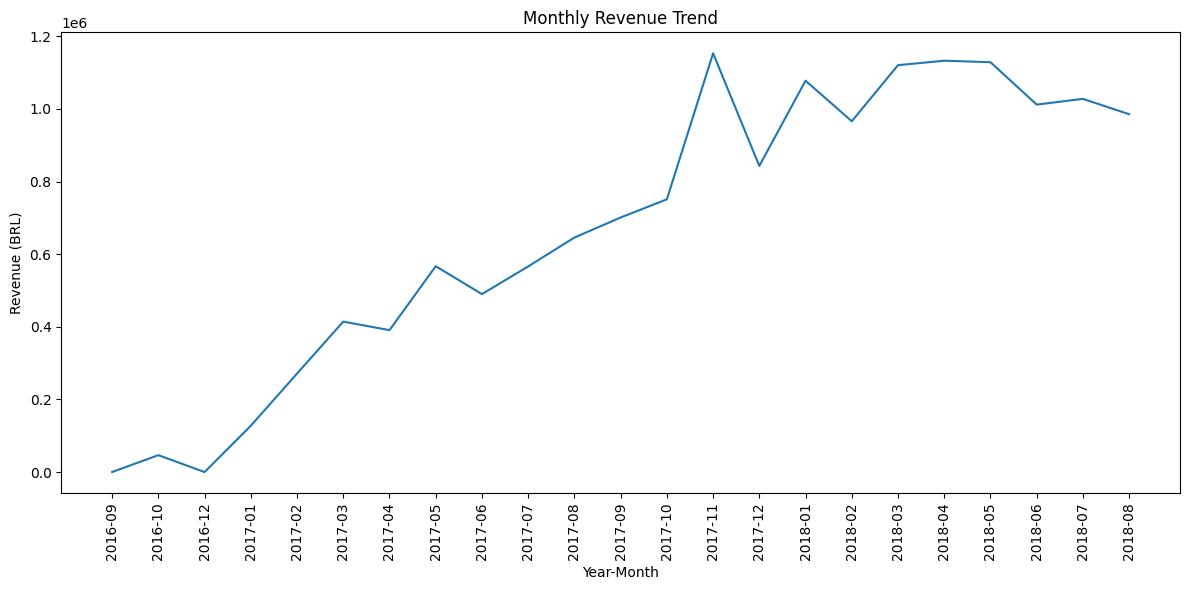

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['year_month'].astype(str), monthly_revenue['item_total_value'])
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue (BRL)")
plt.tight_layout()
plt.show()

In [28]:
order_items = order_items.merge(
    products[['product_id','product_category_name']],
    on='product_id',
    how='left'
)

In [29]:
order_items = order_items.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

In [30]:
category_revenue = (
    order_items.groupby('product_category_name_english')['item_total_value']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head(10)

,product_category_name_english,item_total_value
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
5,furniture_decor,902511.79
6,housewares,778397.77
7,cool_stuff,719329.95
8,auto,685384.32
9,garden_tools,584219.21


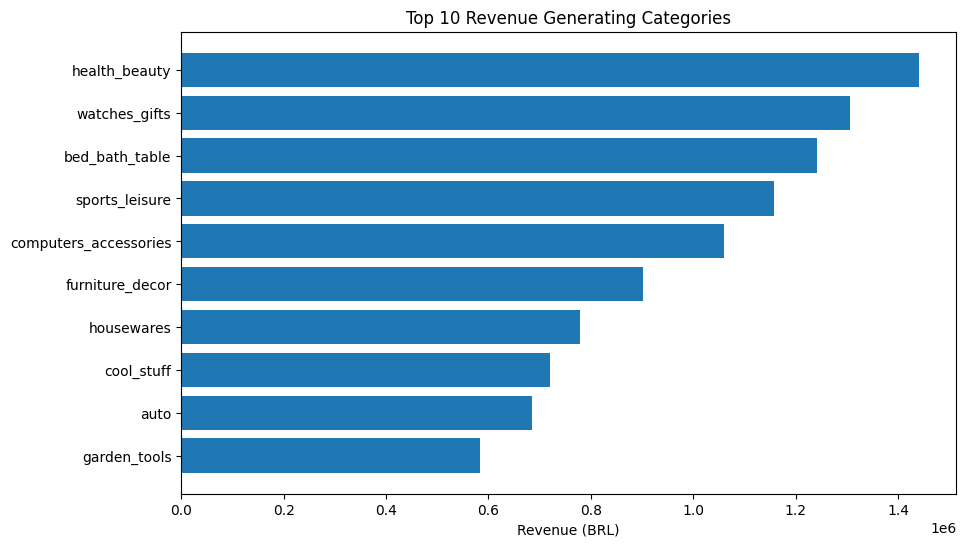

In [31]:
import matplotlib.pyplot as plt

top10 = category_revenue.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['product_category_name_english'], top10['item_total_value'])
plt.gca().invert_yaxis()
plt.title("Top 10 Revenue Generating Categories")
plt.xlabel("Revenue (BRL)")
plt.show()

In [32]:
rfm_data = orders.merge(
    customers[['customer_id','customer_unique_id']],
    on='customer_id',
    how='left'
)

In [33]:
snapshot_date = rfm_data['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2018-08-30 15:00:37')

In [34]:
rfm = rfm_data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'item_total_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id','recency','frequency','monetary']

rfm.head()

,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [35]:
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4


In [36]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


In [37]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return "Champions"
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return "Loyal Customers"
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return "Potential Loyalist"
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return "At Risk"
    else:
        return "Others"

rfm['segment'] = rfm.apply(segment_customer, axis=1)

rfm['segment'].value_counts()

segment
Others                22359
At Risk               22230
Loyal Customers       18824
Potential Loyalist    14984
Champions             14961
Name: count, dtype: int64

In [38]:
total_revenue = rfm['monetary'].sum()
total_revenue

np.float64(15419773.75)

In [39]:
rfm_sorted = rfm.sort_values(by='monetary', ascending=False).reset_index(drop=True)
rfm_sorted.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08,2,1,5,215,Others
1,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63,1,5,5,155,At Risk
2,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88,5,3,5,535,Loyal Customers
3,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31,1,5,5,155,At Risk
4,459bef486812aa25204be022145caa62,35,1,6922.21,5,2,5,525,Potential Loyalist


In [40]:
rfm_sorted['cumulative_revenue'] = rfm_sorted['monetary'].cumsum()
rfm_sorted['cumulative_percentage'] = 100 * rfm_sorted['cumulative_revenue'] / total_revenue
rfm_sorted[['monetary','cumulative_percentage']].head(10)

,monetary,cumulative_percentage
0,13664.08,0.088614
1,7571.63,0.137717
2,7274.88,0.184896
3,6929.31,0.229834
4,6922.21,0.274726
5,6726.66,0.318349
6,6081.54,0.357789
7,4764.34,0.388687
8,4681.78,0.419049
9,4655.88,0.449243


In [41]:
top_80 = rfm_sorted[rfm_sorted['cumulative_percentage'] <= 80]

customer_percentage = 100 * len(top_80) / len(rfm_sorted)
customer_percentage

48.84851860579704